In [2]:
print("Akhilon S - 24BAD008")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

Akhilon S - 24BAD008


SCENARIO 1 – Bagging (Diabetes)

Load Dataset

In [5]:
print("Akhilon S - 24BAD008")

df = pd.read_csv("diabetes_bagging.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

Akhilon S - 24BAD008


Train Decision Tree

In [6]:
print("Akhilon S - 24BAD008")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

Akhilon S - 24BAD008


Apply BaggingClassifier

In [7]:
print("Akhilon S - 24BAD008")
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

Akhilon S - 24BAD008


Compare Accuracy

In [11]:
print("Akhilon S - 24BAD008")
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree:", acc_dt)
print("Bagging:", acc_bag)

Akhilon S - 24BAD008
Decision Tree: 0.9583333333333334
Bagging: 0.9583333333333334


Akhilon S - 24BAD008


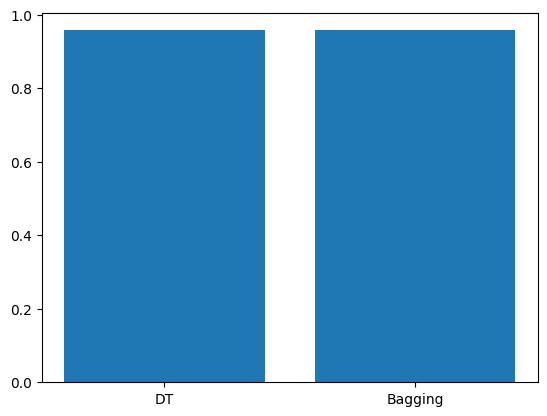

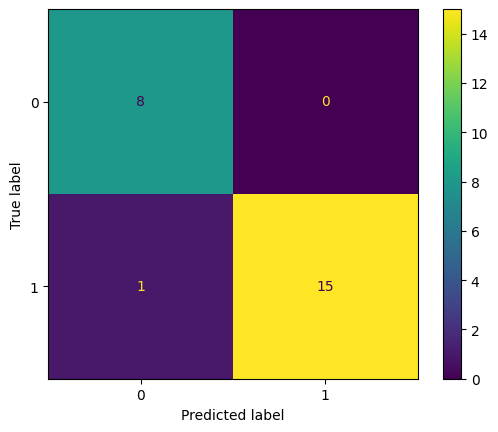

In [12]:
print("Akhilon S - 24BAD008")
# Bar graph
plt.bar(["DT", "Bagging"], [acc_dt, acc_bag])
plt.show()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.show()

SCENARIO 2 – Boosting

Load Dataset

In [16]:
print("Akhilon S - 24BAD008")
df = pd.read_csv("C:\ML_Lab\churn_boosting.csv")
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes":1, "No":0})

X = pd.get_dummies(X)

Akhilon S - 24BAD008


Prepare Features & Target

In [32]:
# Target (already 0/1 — no mapping needed)
y = df["Churn"]

# Features
X = df.drop("Churn", axis=1)

# Convert categorical → numeric
X = pd.get_dummies(X)

Split Dataset

In [39]:
print("Akhilon S - 24BAD008")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ✅ VERY IMPORTANT
)

Akhilon S - 24BAD008


Train AdaBoost

In [40]:
print("Akhilon S - 24BAD008")
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)

Akhilon S - 24BAD008


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


Train Gradient Boosting

In [41]:
print("Akhilon S - 24BAD008")
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

Akhilon S - 24BAD008


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Compare Performance (ROC Curve)

Akhilon S - 24BAD008


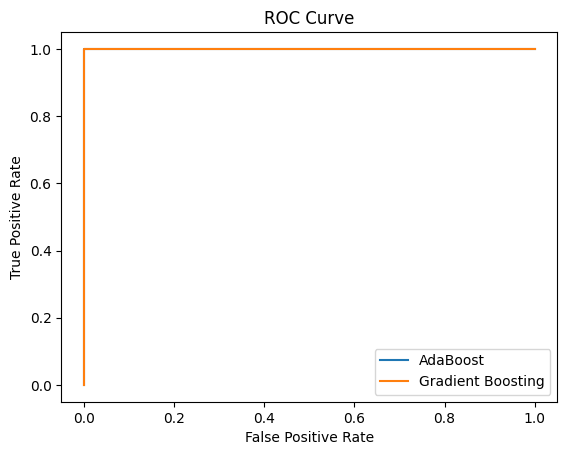

In [42]:
print("Akhilon S - 24BAD008")
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# AdaBoost
y_prob_ada = ada.predict_proba(X_test)[:,1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)

# Gradient Boosting
y_prob_gb = gb.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# Plot
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature Importance Plot

Akhilon S - 24BAD008


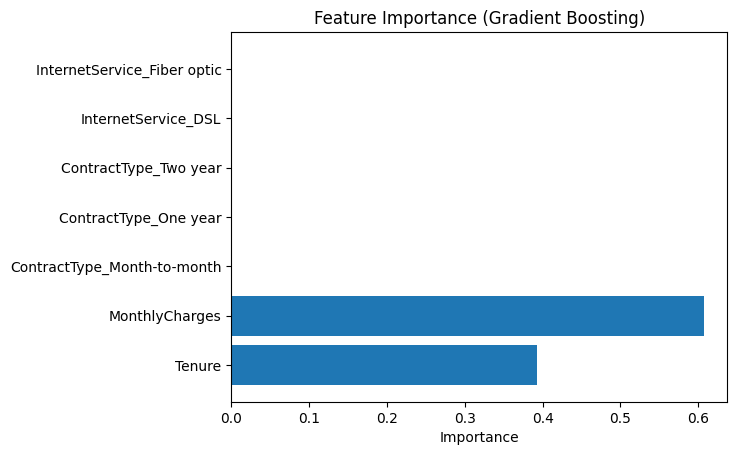

In [37]:
print("Akhilon S - 24BAD008")
importances = gb.feature_importances_

plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

SCENARIO 3 – Random Forest (Adult Income)

Load Dataset

In [48]:
print("Akhilon S - 24BAD008")
import pandas as pd

df = pd.read_csv("C:\ML_Lab\income_random_forest.csv")  # your file name

print(df.head())

# Features & Target
X = df.drop("Income", axis=1)
y = df["Income"]

Akhilon S - 24BAD008
   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1


Train Random Forest

In [57]:
print("Akhilon S - 24BAD008")
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=20,    # fewer trees
    max_depth=4,        # restrict depth
    random_state=42
)

rf.fit(X_train, y_train)

Akhilon S - 24BAD008


,n_estimators,20
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Tune Number of Trees

In [58]:
print("Akhilon S - 24BAD008")
from sklearn.metrics import accuracy_score

trees = [10, 50, 100]
acc = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

Akhilon S - 24BAD008


Evaluate Model

In [59]:
print("Akhilon S - 24BAD008")
print("Accuracy for different trees:", acc)

Akhilon S - 24BAD008
Accuracy for different trees: [1.0, 1.0, 1.0]


Visualization
Accuracy vs Number of Trees

Akhilon S - 24BAD008


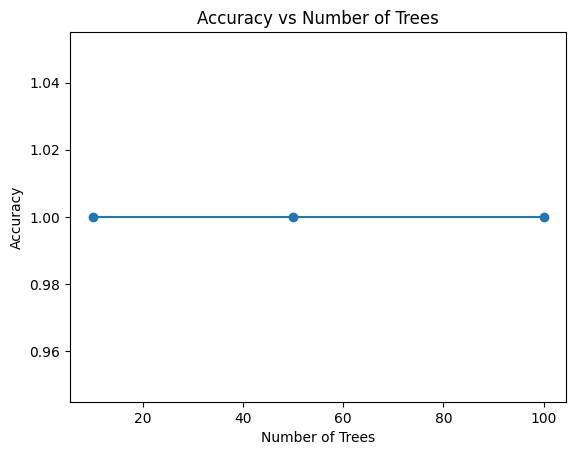

In [60]:
print("Akhilon S - 24BAD008")
import matplotlib.pyplot as plt

plt.plot(trees, acc, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

Feature Importance

Akhilon S - 24BAD008


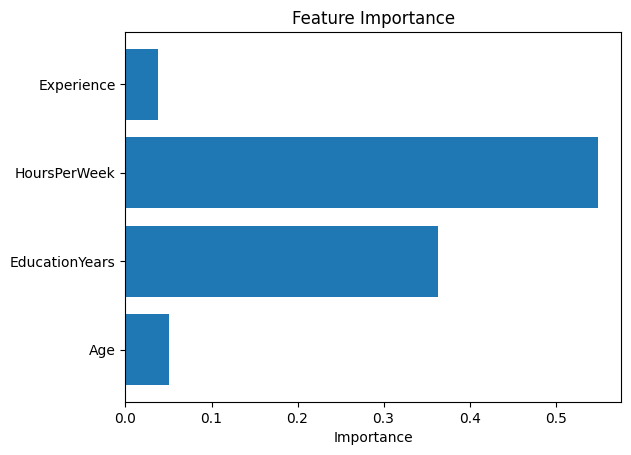

In [61]:
print("Akhilon S - 24BAD008")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

SCENARIO 4 – Stacking (Heart Disease Style)

Load Dataset

In [64]:
import pandas as pd

df = pd.read_csv("C:\ML_Lab\heart_stacking.csv")   # or your dataset
   # your file name
print(df.head())

# Features & Target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0


Train Base Models

In [77]:
df = df.sample(frac=1, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=10
)

svm = SVC(probability=True, C=0.1)

# Train models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Apply Stacking

In [90]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', svm),
        ('dt', dt)
    ],
    final_estimator=LogisticRegression(C=0.1)
)



stack.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svm', ...), ...]"
,final_estimator,LogisticRegression(C=0.1)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Compare with Individual Models

In [91]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Decision Tree": dt,
    "Stacking": stack
}

names = []
acc = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(name, "Accuracy:", accuracy)
    
    names.append(name)
    acc.append(accuracy)

Logistic Regression Accuracy: 0.7777777777777778
SVM Accuracy: 0.6944444444444444
Decision Tree Accuracy: 1.0
Stacking Accuracy: 0.9166666666666666


Visualization (Model Comparison)

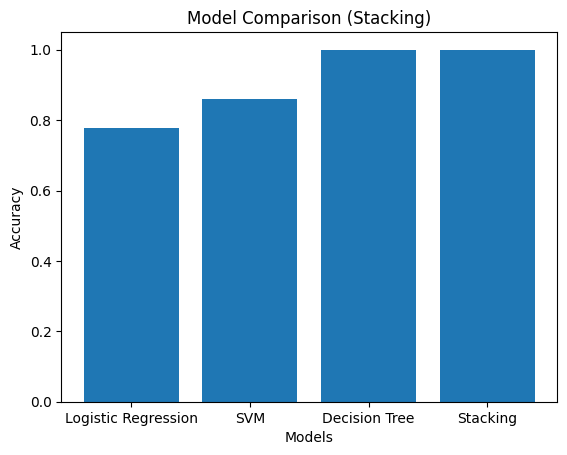

In [68]:
import matplotlib.pyplot as plt

plt.bar(names, acc)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Stacking)")
plt.show()

SCENARIO 5 – SMOTE (Fraud Detection)

Load Dataset

In [96]:
import pandas as pd

df = pd.read_csv("fraud_smote.csv")   # your file

print(df.head())

# Features & Target
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0


Check Class Imbalance

In [97]:
print("Before SMOTE:")
print(y.value_counts())

Before SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64


Train Model BEFORE SMOTE

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

print("Before SMOTE:\n")
print(classification_report(y_test, y_pred_before))

Before SMOTE:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        33
           1       0.00      0.00      0.00         3

    accuracy                           0.92        36
   macro avg       0.46      0.50      0.48        36
weighted avg       0.84      0.92      0.88        36



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Apply SMOTE

In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
Fraud
0    77
1    77
Name: count, dtype: int64


Train Model AFTER SMOTE

In [102]:
model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_res, y_res)

y_pred_after = model_after.predict(X_test)

print("After SMOTE:\n")
print(classification_report(y_test, y_pred_after))

After SMOTE:

              precision    recall  f1-score   support

           0       0.90      0.79      0.84        33
           1       0.00      0.00      0.00         3

    accuracy                           0.72        36
   macro avg       0.45      0.39      0.42        36
weighted avg       0.82      0.72      0.77        36



Visualization 1: Class Distribution

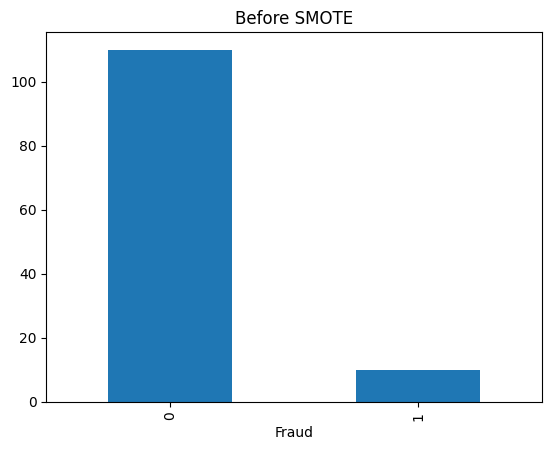

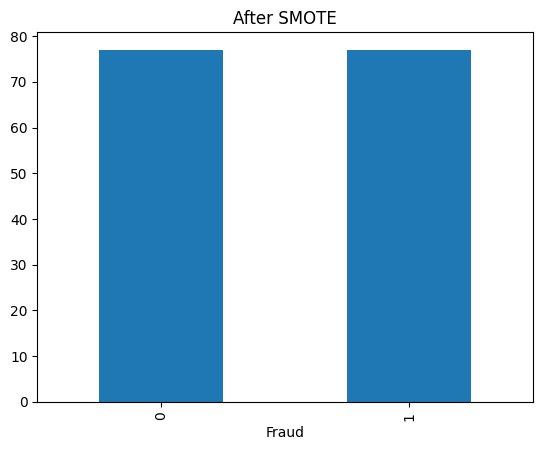

In [104]:
import matplotlib.pyplot as plt

# Before
y.value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.show()

# After
pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.show()

Visualization 2: Precision-Recall Curve

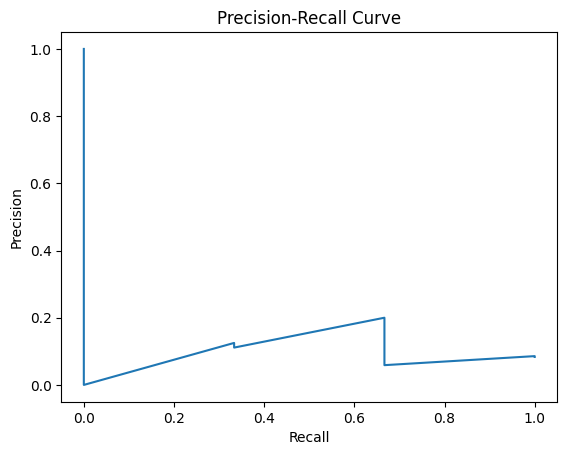

In [105]:
from sklearn.metrics import precision_recall_curve

y_prob = model_after.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()